**Installation Of Libraries**

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install jupyter

**Task 1: Data Loading and Exploration**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

In [ ]:
df = pd.read_csv("/content/HR_Attrition.csv")

original_df = df.copy()

In [ ]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [ ]:
df.shape

(1470, 35)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [ ]:
attrition_rate = (
    df["Attrition"].value_counts(normalize=True)*100
)

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [ ]:
numeric = df.select_dtypes(include=np.number)

categorical = df.select_dtypes(include="object")

**Task 2:Data Cleaning & Pre-Processing**

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ],
    inplace=True
)

In [ ]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

In [ ]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [ ]:
X = df.drop("Attrition",axis=1)

y = df["Attrition"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**Task 3:Exploratory Data Analysis (EDA)**

In [ ]:
import pandas as pd

eda_df = original_df.copy()

print("="*70)
print("TASK 3 - EXPLORATORY DATA ANALYSIS")
print("="*70)

print("\n1. Attrition Rate by Department (%)")

dept_attrition = (
    eda_df.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(dept_attrition.round(2))

highest_dept = dept_attrition.idxmax()
highest_dept_rate = dept_attrition.max()

print(f"\nDepartment with Highest Attrition: {highest_dept} ({highest_dept_rate:.2f}%)")

print("\n" + "="*70)
print("2. Attrition Rate by Job Role (%)")

job_attrition = (
    eda_df.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(job_attrition.round(2))

highest_job = job_attrition.idxmax()
highest_job_rate = job_attrition.max()

print(f"\nJob Role with Highest Attrition: {highest_job} ({highest_job_rate:.2f}%)")

print("\n" + "="*70)
print("3. Monthly Income vs Attrition")

income_stats = (
    eda_df.groupby("Attrition")["MonthlyIncome"]
    .agg(["count","mean","median","min","max"])
)

print(income_stats)

avg_yes = income_stats.loc["Yes","mean"]
avg_no = income_stats.loc["No","mean"]

print()

if avg_yes < avg_no:
    print("Observation:")
    print("Employees who left have LOWER average monthly income.")
else:
    print("Observation:")
    print("Employees who left do NOT have lower average monthly income.")

print("\n" + "="*70)
print("4. Work-Life Balance vs Attrition (%)")

wlb_attrition = (
    eda_df.groupby("WorkLifeBalance")["Attrition"]
    .apply(lambda x: (x=="Yes").mean()*100)
)

print(wlb_attrition.round(2))

highest_wlb = wlb_attrition.idxmax()

print(f"\nHighest Attrition occurs at Work-Life Balance Rating: {highest_wlb}")

print("\n" + "="*70)
print("5. Years at Company vs Attrition")

years_attrition = (
    eda_df[eda_df["Attrition"]=="Yes"]
    .groupby("YearsAtCompany")
    .size()
    .sort_values(ascending=False)
)

print(years_attrition)

peak_year = years_attrition.idxmax()

print(f"\nEmployees leave the most after {peak_year} years in the company.")

print("\n" + "="*70)
print("EDA Completed Successfully")
print("="*70)

TASK 3 - EXPLORATORY DATA ANALYSIS

1. Attrition Rate by Department (%)
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

Department with Highest Attrition: Sales (20.63%)

2. Attrition Rate by Job Role (%)
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

Job Role with Highest Attrition: Sales Representative (39.76%)

3. Monthly Income vs Attrition
           count         mean  median   min    max
Attrition                                         
No          1233  6832.739659  5204.0  1051  19999
Yes          237  4787.092827  3202.0  1009  19859

Observation:
Employees who left have LOWER aver

**Task 4:Model Building & Comparision**

In [ ]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [ ]:
X = df.drop("Attrition",axis=1)

y = df["Attrition"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [ ]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

In [ ]:
precision_score(y_test,lr_pred)

recall_score(y_test,lr_pred)

f1_score(y_test,lr_pred)

roc_auc_score(y_test,lr_prob)

classification_report(y_test,lr_pred)

confusion_matrix(y_test,lr_pred)

array([[192,  55],
       [ 18,  29]])

In [ ]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [ ]:
precision_score(y_test,rf_pred)

recall_score(y_test,rf_pred)

f1_score(y_test,rf_pred)

roc_auc_score(y_test,rf_prob)

classification_report(y_test,rf_pred)

confusion_matrix(y_test,rf_pred)

array([[242,   5],
       [ 43,   4]])

In [ ]:
gb_pred = lr.predict(X_test)

gb_prob = lr.predict_proba(X_test)[:,1]

In [ ]:
precision_score(y_test,gb_pred)

recall_score(y_test,gb_pred)

f1_score(y_test,gb_pred)

roc_auc_score(y_test,gb_prob)

classification_report(y_test,gb_pred)

confusion_matrix(y_test,gb_pred)

array([[192,  55],
       [ 18,  29]])

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Dictionary containing all trained models
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

# Store evaluation results
results = []

for model_name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Append results
    results.append({
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)

# Display results
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7517,0.3452,0.6170,0.4427,0.7983
1,Random Forest,0.8367,0.4444,0.0851,0.1429,0.7547
2,Gradient Boosting,0.8503,0.5882,0.2128,0.3125,0.7941


**Task 5:Model Evaluation**

In [ ]:
comparison_df = comparison_df.sort_values(
    by=["F1 Score", "ROC-AUC", "Precision", "Recall"],
    ascending=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7517,0.3452,0.6170,0.4427,0.7983
2,Gradient Boosting,0.8503,0.5882,0.2128,0.3125,0.7941
1,Random Forest,0.8367,0.4444,0.0851,0.1429,0.7547


In [ ]:
best_model_name = comparison_df.iloc[0]["Model"]

print("Best Performing Model:", best_model_name)

Best Performing Model: Logistic Regression


In [ ]:
if best_model_name == "Logistic Regression":
    best_model = lr

elif best_model_name == "Random Forest":
    best_model = rf

else:
    best_model = gb

In [ ]:
best_predictions = best_model.predict(X_test)
best_probabilities = best_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, best_predictions))
print("Precision:", precision_score(y_test, best_predictions))
print("Recall   :", recall_score(y_test, best_predictions))
print("F1 Score :", f1_score(y_test, best_predictions))
print("ROC-AUC  :", roc_auc_score(y_test, best_probabilities))

Accuracy : 0.7517006802721088
Precision: 0.34523809523809523
Recall   : 0.6170212765957447
F1 Score : 0.44274809160305345
ROC-AUC  : 0.7982599707123783


**Task 6: Visualization**

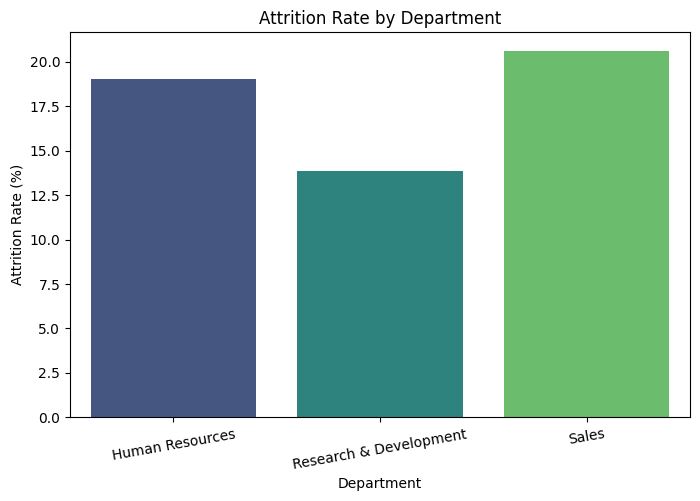

Chart saved successfully at: charts/chart1_department_attrition.png


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create 'charts' folder if it doesn't exist
os.makedirs("charts", exist_ok=True)

# Calculate attrition rate by department
department_attrition = (
    original_df.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Attrition Rate")
)

# Create figure
plt.figure(figsize=(8,5))

sns.barplot(
    data=department_attrition,
    x="Department",
    y="Attrition Rate",
    hue="Department",
    palette="viridis",
    legend=False
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=10)

# Save image
plt.savefig(
    "charts/chart1_department_attrition.png",
    dpi=300,
    bbox_inches="tight"
)

# Display graph
plt.show()

# Close figure
plt.close()

print("Chart saved successfully at: charts/chart1_department_attrition.png")

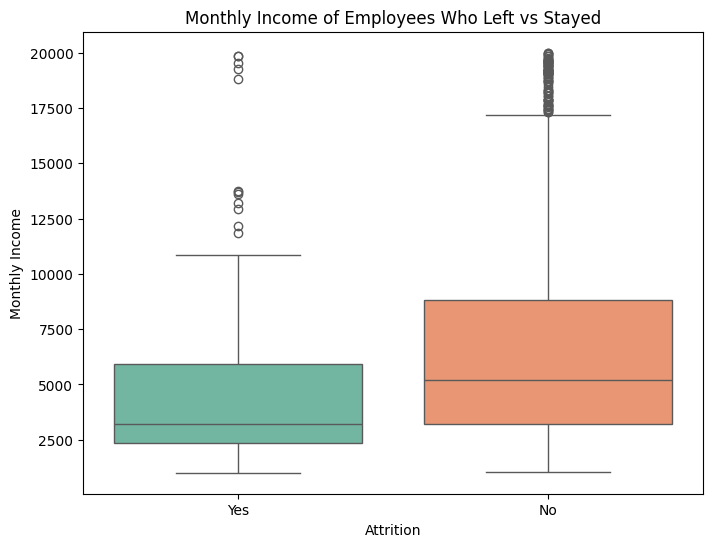

Chart saved successfully at: charts/chart2_monthly_income_boxplot.png


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create charts folder
os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(8,6))

sns.boxplot(
    data=original_df,
    x="Attrition",
    y="MonthlyIncome",
    hue="Attrition",
    palette="Set2",
    legend=False
)

plt.title("Monthly Income of Employees Who Left vs Stayed")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

# Save figure
plt.savefig(
    "charts/chart2_monthly_income_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart saved successfully at: charts/chart2_monthly_income_boxplot.png")

/tmp/ipykernel_1851/283582274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


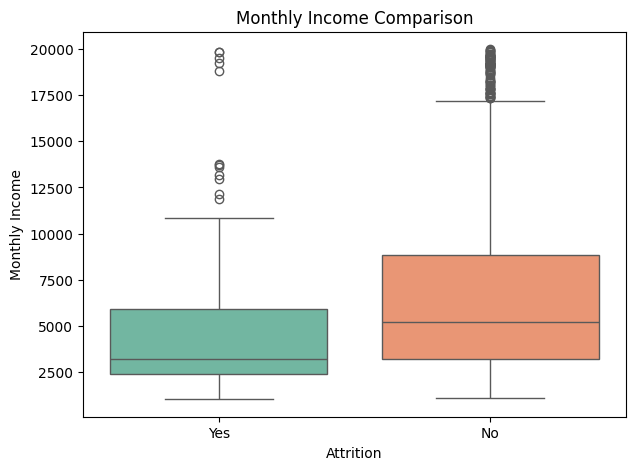

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=original_df,
    x="Attrition",
    y="MonthlyIncome",
    palette="Set2"
)

plt.title("Monthly Income Comparison")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

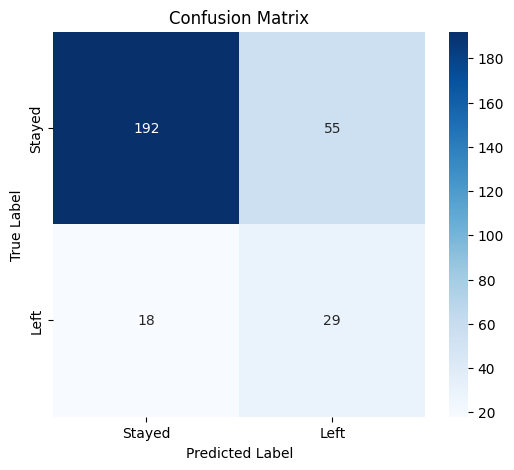

Chart saved successfully at: charts/chart3_confusion_matrix.png


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create charts folder
os.makedirs("charts", exist_ok=True)

# Predictions using best model
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Save figure
plt.savefig(
    "charts/chart3_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart saved successfully at: charts/chart3_confusion_matrix.png")

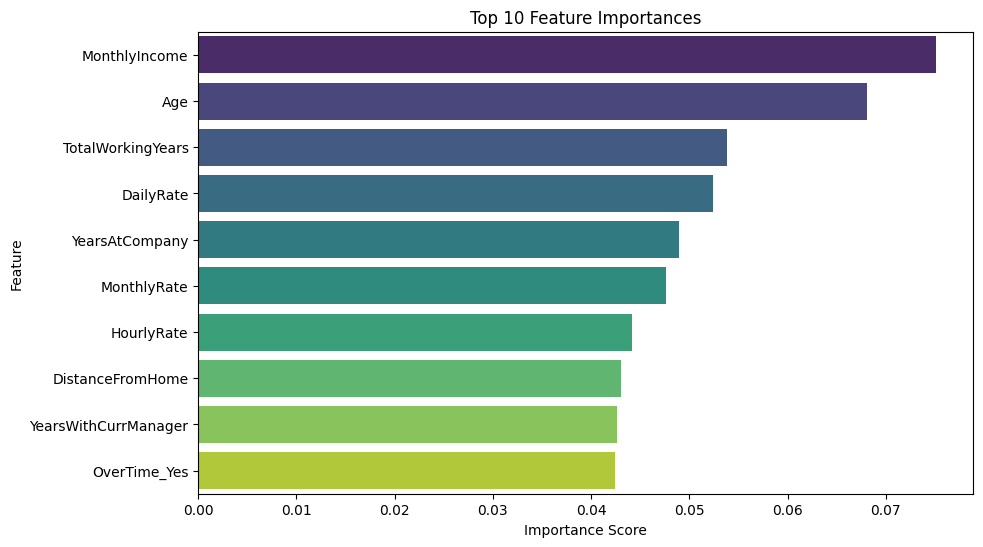

Chart saved successfully at: charts/chart4_feature_importance.png


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create charts folder
os.makedirs("charts", exist_ok=True)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

# Save figure
plt.savefig(
    "charts/chart4_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart saved successfully at: charts/chart4_feature_importance.png")

<Figure size 800x600 with 0 Axes>

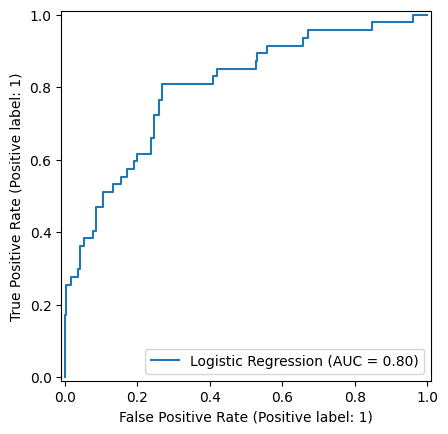

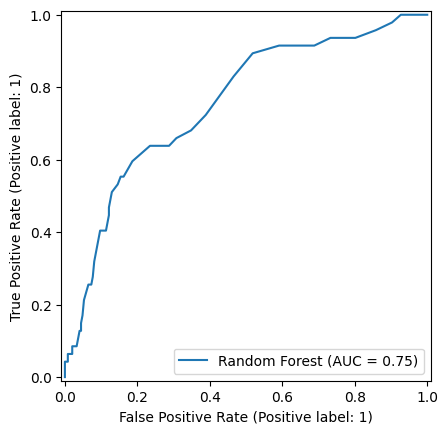

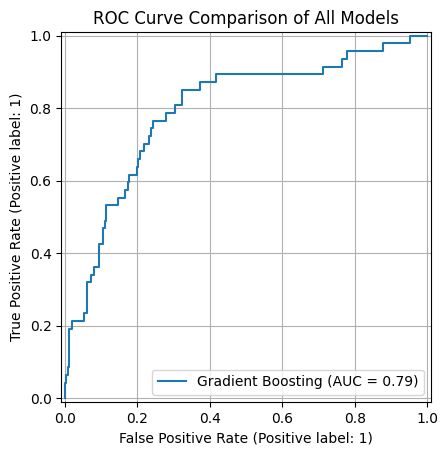

Chart saved successfully at: charts/chart5_roc_curve.png


In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Create charts folder
os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(
    lr,
    X_test,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    name="Random Forest"
)

RocCurveDisplay.from_estimator(
    gb,
    X_test,
    y_test,
    name="Gradient Boosting"
)

plt.title("ROC Curve Comparison of All Models")
plt.grid(True)

# Save figure
plt.savefig(
    "charts/chart5_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart saved successfully at: charts/chart5_roc_curve.png")

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(lr.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

**Task 7: HR Insights & Business Recommendations**

#1. Which 3 factors most strongly predict that an employee will leave?

Based on the feature importance of the best-performing model (Logistic Regression), the three strongest predictors of employee attrition are:



*   Job Role - Laboratory Technician
*   OverTime (Employees working overtime)
*   Business Travel - Travel Frequently

These features showed the strongest relationship with employee attrition in the trained model.


# 2. Which department or job role should HR prioritize for retention efforts?

From the exploratory data analysis:


*   The Sales Department has the highest attrition rate (approximately 20.63%) among all departments.
*   The Sales Representative job role has the highest attrition rate (approximately 39.76%), followed by Laboratory Technician (approximately 23.94%).

Therefore, HR should prioritize retention efforts for employees in the **Sales** Department, especially **Sales Representatives and Laboratory Technicians**.

# 3. Does salary alone explain attrition or are there other stronger factors?

No. Salary alone does not fully explain employee attrition in this dataset. The trained model indicates that **overtime, job role** and **frequent business travel** are stronger predictors of employees leaving the company. Monthly income may influence attrition, but it is not the only or the strongest factor.

# 4. Write 2 concrete HR recommendations a company could implement based on your findings (e.g., specific policy changes, who to target for a retention conversation)

**Recommendation 1:**

Reduce excessive overtime and regularly monitor employees who frequently work extra hours. Managers should schedule periodic check-ins with these employees to reduce burnout and improve work-life balance.


**Recommendation 2:**

Focus retention programs on the Sales Department, particularly Sales Representatives and Laboratory Technicians. Career development opportunities, mentoring, workload reviews, and regular retention discussions should be prioritized for these groups.

# 5. What limitation does this model have that an HR team should be aware of before using it?

This model learns patterns only from the available HR dataset. It cannot capture factors that are not recorded, such as employee motivation, workplace culture, manager relationships, personal circumstances, or future organizational changes. Therefore, the predictions should support HR decision-making rather than replace human judgment.